In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

from scipy.spatial.distance import cdist
from sklearn.metrics import roc_curve, auc

In [2]:
DATA_FILE = "biomet_data.csv"

N_USERS = 100
N_SAMPLES_PER_USER = 10
N_TRAIN = 5
N_TEST = 5
N_FEATURES = 144

OUTPUT_DIR = "results"

In [3]:
def load_data(file_path):
    df = pd.read_csv(
        file_path,
        sep="\t",
        header=None
    )
    df = df.dropna(axis=1, how="all")

    data = df.to_numpy(dtype=float)

    print("Raw data shape:", data.shape)


    data = data.T

    print("Final data shape:", data.shape)

    return data

data_df=load_data(DATA_FILE)

def split_data(data):
    data = data.reshape(
        N_USERS,
        N_SAMPLES_PER_USER,
        N_FEATURES
    )

    enrollment = data[:, :N_TRAIN, :]
    test = data[:, N_TRAIN:, :]

    print("\nEnrollment shape:", enrollment.shape)
    print("Test shape:", test.shape)

    return enrollment, test


enrollment_df,test_df=split_data(data_df)

Raw data shape: (144, 1000)
Final data shape: (1000, 144)

Enrollment shape: (100, 5, 144)
Test shape: (100, 5, 144)


In [4]:
def create_templates(enrollment_df):

    templates = np.mean(enrollment_df, axis=1)

    print("\nTemplates shape:", templates.shape)

    return templates
enrollment_templates=create_templates(enrollment_df)


Templates shape: (100, 144)


In [5]:
def distance_metric(test_samples,templates,metric):
  if metric=="euclidean":
    euclidean_matrix=cdist(test_samples,templates,metric="euclidean")
    return euclidean_matrix
  if metric=="cosine":
    cosine_matrix=1-cdist(test_samples,templates,metric="cosine")
    return cosine_matrix

In [6]:
test_samples=test_df.reshape(N_USERS*N_TEST,N_FEATURES)
test_users_ids=np.repeat(np.arange(N_USERS),N_TEST)

In [7]:
def generate_comparisons(test_samples, templates, test_user_ids):

    euclidean_matrix = distance_metric(test_samples, templates, metric="euclidean")
    cosine_matrix = distance_metric(test_samples, templates, metric="cosine")


    genuine_euclidean = []
    impostor_euclidean = []
    genuine_cosine = []
    impostor_cosine = []


    for test_index, true_user in enumerate(test_user_ids):
        for template_user in range(N_USERS):
            euclidean_score = euclidean_matrix[test_index, template_user]
            cosine_score = cosine_matrix[test_index, template_user]

            if template_user == true_user:
                genuine_euclidean.append(euclidean_score)
                genuine_cosine.append(cosine_score)
            else:
                impostor_euclidean.append(euclidean_score)
                impostor_cosine.append(cosine_score)


    genuine_euclidean = np.array(genuine_euclidean)
    impostor_euclidean = np.array(impostor_euclidean)
    genuine_cosine = np.array(genuine_cosine)
    impostor_cosine = np.array(impostor_cosine)


    print("\nComparison counts")
    print("Genuine:", len(genuine_euclidean))
    print("Impostor:", len(impostor_euclidean))

    return (
        genuine_euclidean,
        impostor_euclidean,
        genuine_cosine,
        impostor_cosine
    )



In [8]:
def plot_score_distributions(
        genuine,
        impostor,
        metric_name,
        higher_is_better=False,
        ax=None
):
    standalone = ax is None

    if standalone:
        fig, ax = plt.subplots(figsize=(10, 6))

    genuine_mean = np.mean(genuine)
    impostor_mean = np.mean(impostor)

    ax.hist(
        genuine,
        bins=50,
        density=True,
        alpha=0.65,
        label="Genuine"
    )

    ax.hist(
        impostor,
        bins=50,
        density=True,
        alpha=0.65,
        label="Impostor"
    )

    ax.axvline(
        genuine_mean,
        linestyle="--",
        linewidth=2,
        label=f"Genuine Mean = {genuine_mean:.2f}"
    )

    ax.axvline(
        impostor_mean,
        linestyle="--",
        linewidth=2,
        label=f"Impostor Mean = {impostor_mean:.2f}"
    )

    ax.set_xlabel(metric_name)
    ax.set_ylabel("Density")

    ax.set_title(
        f"Genuine vs Impostor Distribution - {metric_name}",
        fontsize=16
    )

    ax.legend()
    ax.grid(alpha=0.25)

    if standalone:
        plt.tight_layout()

        filename = (
            f"{OUTPUT_DIR}/"
            f"{metric_name.lower().replace(' ', '_')}_distribution.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

In [9]:
def calculate_far_frr(genuine, impostor, thresholds, higher_is_better):
    far = []
    frr = []

    for threshold in thresholds:
        if higher_is_better:
            genuine_accept = genuine >= threshold
            impostor_accept = impostor >= threshold
        else:
            genuine_accept = genuine <= threshold
            impostor_accept = impostor <= threshold

        false_acceptances = np.sum(impostor_accept)
        false_rejections = np.sum(~genuine_accept)

        FAR = false_acceptances / len(impostor)
        FRR = false_rejections / len(genuine)

        far.append(FAR)
        frr.append(FRR)

    return np.array(far), np.array(frr)

In [10]:
def calculate_eer(genuine, impostor, higher_is_better):
    if higher_is_better:
        genuine_scores = genuine
        impostor_scores = impostor
    else:
        genuine_scores = -genuine
        impostor_scores = -impostor

    scores = np.concatenate([genuine_scores, impostor_scores])
    labels = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))])

    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    index = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[index] + fnr[index]) / 2
    eer_threshold = thresholds[index]

    if not higher_is_better:
        eer_threshold = -eer_threshold

    return eer, eer_threshold

In [11]:
def plot_roc(
        genuine,
        impostor,
        metric_name,
        output_dir,
        higher_is_better,
        ax=None
):
    standalone = ax is None

    if higher_is_better:
        genuine_scores = genuine
        impostor_scores = impostor
    else:
        genuine_scores = -genuine
        impostor_scores = -impostor

    scores = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    labels = np.concatenate([
        np.ones(len(genuine_scores)),
        np.zeros(len(impostor_scores))
    ])

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    fnr = 1 - tpr

    eer_index = np.argmin(
        np.abs(fpr - fnr)
    )

    eer = (
        fpr[eer_index] +
        fnr[eer_index]
    ) / 2

    eer_fpr = fpr[eer_index]
    eer_tpr = tpr[eer_index]

    if standalone:
        fig, ax = plt.subplots(figsize=(8, 7))

    ax.plot(
        fpr * 100,
        tpr * 100,
        label=f"ROC (AUC = {roc_auc:.4f})"
    )

    ax.plot(
        [0, 100],
        [0, 100],
        linestyle="--",
        label="Random"
    )

    ax.scatter(
        eer_fpr * 100,
        eer_tpr * 100,
        s=100,
        zorder=5,
        label=f"EER = {eer * 100:.2f}%"
    )

    ax.set_xlabel(
        "False Acceptance Rate (FAR) (%)"
    )

    ax.set_ylabel(
        "True Acceptance Rate (TAR) (%)"
    )

    ax.set_title(
        f"ROC Curve - {metric_name}"
    )

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    ax.legend()
    ax.grid(alpha=0.3)

    if standalone:
        plt.tight_layout()

        filename = (
            f"{output_dir}/"
            f"{metric_name.lower().replace(' ', '_')}_roc.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    return fpr, tpr, roc_auc

In [12]:
def plot_far_frr(
        genuine,
        impostor,
        metric_name,
        higher_is_better,
        ax=None
):
    standalone = ax is None

    min_score = min(
        genuine.min(),
        impostor.min()
    )

    max_score = max(
        genuine.max(),
        impostor.max()
    )

    thresholds = np.linspace(
        min_score,
        max_score,
        1000
    )

    far, frr = calculate_far_frr(
        genuine,
        impostor,
        thresholds,
        higher_is_better
    )

    if standalone:
        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

    ax.plot(
        thresholds,
        far * 100,
        label="FAR"
    )

    ax.plot(
        thresholds,
        frr * 100,
        label="FRR"
    )

    ax.set_xlabel(
        "Threshold"
    )

    ax.set_ylabel(
        "Error Rate (%)"
    )

    ax.set_title(
        f"FAR and FRR - {metric_name}"
    )

    ax.legend()
    ax.grid(alpha=0.3)

    if standalone:
        plt.tight_layout()

        filename = os.path.join(
            OUTPUT_DIR,
            f"{metric_name.lower().replace(' ', '_')}_far_frr.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    return thresholds, far, frr

In [13]:
def calculate_decidability_index(genuine, impostor):
    mu_g = np.mean(genuine)
    mu_i = np.mean(impostor)

    sigma_g = np.std(genuine, ddof=1)
    sigma_i = np.std(impostor, ddof=1)

    d_prime = abs(mu_g - mu_i) / np.sqrt((sigma_g**2 + sigma_i**2) / 2)

    return d_prime

In [20]:
def print_statistics(genuine, impostor, metric_name, higher_is_better):

    print(metric_name.upper())


    print("\nGenuine Distribution")
    print(f"Mean       : {np.mean(genuine):.6f}")
    print(f"Std        : {np.std(genuine, ddof=1):.6f}")
    print(f"Minimum    : {np.min(genuine):.6f}")
    print(f"Maximum    : {np.max(genuine):.6f}")

    print("\nImpostor Distribution")
    print(f"Mean       : {np.mean(impostor):.6f}")
    print(f"Std        : {np.std(impostor, ddof=1):.6f}")
    print(f"Minimum    : {np.min(impostor):.6f}")
    print(f"Maximum    : {np.max(impostor):.6f}")

    eer, threshold = calculate_eer(genuine, impostor, higher_is_better)
    d_prime = calculate_decidability_index(genuine, impostor)

    print("\nPerformance")
    print(f"EER        : {eer * 100:.4f}%")
    print(f"EER score  : {threshold:.6f}")
    print(f"Decidability Index (d') : {d_prime:.6f}")

    return eer, threshold, d_prime

In [15]:
def save_scores(
    genuine_euclidean, impostor_euclidean, genuine_cosine, impostor_cosine
):
    pd.DataFrame({
        "genuine_euclidean": pd.Series(genuine_euclidean),
        "impostor_euclidean": pd.Series(impostor_euclidean),
        "genuine_cosine": pd.Series(genuine_cosine),
        "impostor_cosine": pd.Series(impostor_cosine),
    }).to_csv(f"{OUTPUT_DIR}/scores.csv", index=False)

In [22]:
def print_final_comparison(
    euclidean_eer, euclidean_dprime, cosine_eer, cosine_dprime
):
    print("\n")

    print("FINAL COMPARISON")


    print(f"\n{'Metric':<25}{'Euclidean':<20}{'Cosine':<20}")
    print("-" * 65)

    print(
        f"{'EER':<25}"
        f"{euclidean_eer * 100:<20.4f}"
        f"{cosine_eer * 100:<20.4f}"
    )
    print(
        f"{'Decidability Index':<25}"
        f"{euclidean_dprime:<20.4f}"
        f"{cosine_dprime:<20.4f}"
    )

    print("\nInterpretation:")

    if euclidean_eer < cosine_eer:
        print("Euclidean distance gives lower EER.")
    else:
        print("Cosine similarity gives lower EER.")

    if euclidean_dprime > cosine_dprime:
        print(
            "Euclidean distance gives better distribution separation according to d'."
        )
    else:
        print(
            "Cosine similarity gives better distribution separation according to d'."
        )


In [17]:
def combined_plot(
        genuine_euclidean,
        impostor_euclidean,
        genuine_cosine,
        impostor_cosine,
        output_dir
):
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(20, 11)
    )

    plot_score_distributions(
        genuine_euclidean,
        impostor_euclidean,
        "Euclidean Distance",
        higher_is_better=False,
        ax=axes[0, 0]
    )

    plot_far_frr(
        genuine_euclidean,
        impostor_euclidean,
        "Euclidean Distance",
        higher_is_better=False,
        ax=axes[0, 1]
    )

    euclidean_fpr, euclidean_tpr, euclidean_auc = plot_roc(
        genuine_euclidean,
        impostor_euclidean,
        "Euclidean Distance",
        output_dir,
        higher_is_better=False,
        ax=axes[0, 2]
    )

    plot_score_distributions(
        genuine_cosine,
        impostor_cosine,
        "Cosine Similarity",
        higher_is_better=True,
        ax=axes[1, 0]
    )

    plot_far_frr(
        genuine_cosine,
        impostor_cosine,
        "Cosine Similarity",
        higher_is_better=True,
        ax=axes[1, 1]
    )

    cosine_fpr, cosine_tpr, cosine_auc = plot_roc(
        genuine_cosine,
        impostor_cosine,
        "Cosine Similarity",
        output_dir,
        higher_is_better=True,
        ax=axes[1, 2]
    )

    fig.suptitle(
        "Biometric Authentication Performance Evaluation",
        fontsize=20
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    filename = os.path.join(
        output_dir,
        "combined_biometric_results.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return (
        euclidean_fpr,
        euclidean_tpr,
        euclidean_auc,
        cosine_fpr,
        cosine_tpr,
        cosine_auc
    )

In [23]:
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("BIOMETRIC AUTHENTICATION PERFORMANCE EVALUATION")


    data = load_data(DATA_FILE)
    enrollment, test = split_data(data)
    templates = create_templates(enrollment)

    (
        genuine_euclidean,
        impostor_euclidean,
        genuine_cosine,
        impostor_cosine,
    ) = generate_comparisons(
        test_samples,
        templates,
        test_users_ids
    )

    save_scores(
        genuine_euclidean,
        impostor_euclidean,
        genuine_cosine,
        impostor_cosine
    )

    print("\n\n")

    print("# EUCLIDEAN DISTANCE")


    euclidean_eer, euclidean_threshold, euclidean_dprime = print_statistics(
        genuine_euclidean,
        impostor_euclidean,
        "Euclidean Distance",
        higher_is_better=False,
    )

    print("\n\n")

    print("# COSINE SIMILARITY")


    cosine_eer, cosine_threshold, cosine_dprime = print_statistics(
        genuine_cosine,
        impostor_cosine,
        "Cosine Similarity",
        higher_is_better=True,
    )

    (
        euclidean_fpr,
        euclidean_tpr,
        euclidean_auc,
        cosine_fpr,
        cosine_tpr,
        cosine_auc
    ) = combined_plot(
        genuine_euclidean,
        impostor_euclidean,
        genuine_cosine,
        impostor_cosine,
        OUTPUT_DIR
    )

    print_final_comparison(
        euclidean_eer,
        euclidean_dprime,
        cosine_eer,
        cosine_dprime
    )

    print("\n")

    print("AUC RESULTS")


    print(f"Euclidean ROC AUC : {euclidean_auc:.6f}")
    print(f"Cosine ROC AUC    : {cosine_auc:.6f}")

    print("\nAll plots and scores have been saved in:")
    print(f"    {OUTPUT_DIR}/")

BIOMETRIC AUTHENTICATION PERFORMANCE EVALUATION
Raw data shape: (144, 1000)
Final data shape: (1000, 144)

Enrollment shape: (100, 5, 144)
Test shape: (100, 5, 144)

Templates shape: (100, 144)

Comparison counts
Genuine: 500
Impostor: 49500



# EUCLIDEAN DISTANCE
EUCLIDEAN DISTANCE

Genuine Distribution
Mean       : 291.616047
Std        : 135.595397
Minimum    : 95.992907
Maximum    : 1018.381952

Impostor Distribution
Mean       : 703.822776
Std        : 301.794848
Minimum    : 215.255317
Maximum    : 2274.138206

Performance
EER        : 11.5556%
EER score  : 429.225434
Decidability Index (d') : 1.761935



# COSINE SIMILARITY
COSINE SIMILARITY

Genuine Distribution
Mean       : 0.989501
Std        : 0.010968
Minimum    : 0.882855
Maximum    : 0.998507

Impostor Distribution
Mean       : 0.960376
Std        : 0.018367
Minimum    : 0.820040
Maximum    : 0.991292

Performance
EER        : 8.4616%
EER score  : 0.978941
Decidability Index (d') : 1.925414


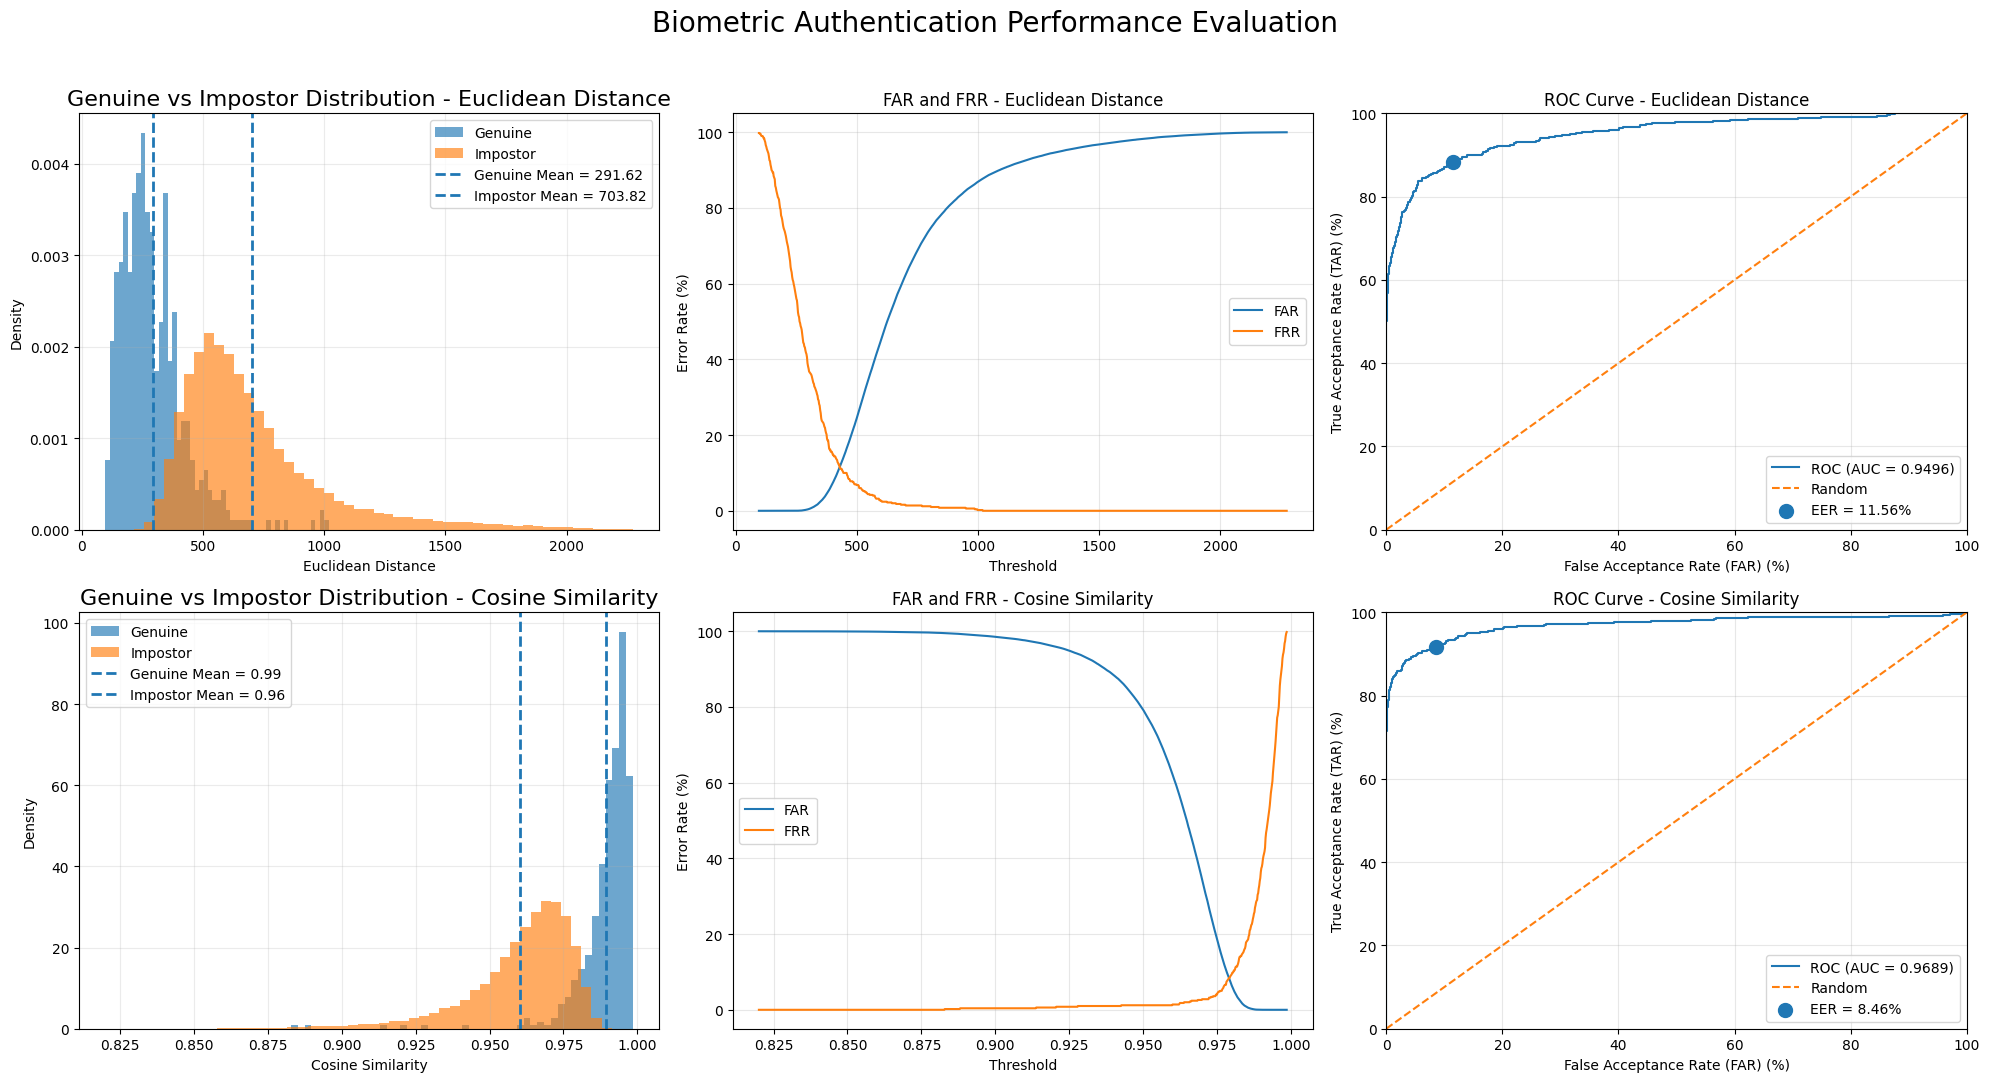



FINAL COMPARISON

Metric                   Euclidean           Cosine              
-----------------------------------------------------------------
EER                      11.5556             8.4616              
Decidability Index       1.7619              1.9254              

Interpretation:
Cosine similarity gives lower EER.
Cosine similarity gives better distribution separation according to d'.


AUC RESULTS
Euclidean ROC AUC : 0.949556
Cosine ROC AUC    : 0.968943

All plots and scores have been saved in:
    results/


In [24]:
main()